In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import datasets

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [3]:
tranform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),

])

train = datasets.MNIST(root="dataset", train=True, download=True,transform=tranform)
test = datasets.MNIST(root="dataset", train=False, download=True,transform=tranform)

# images: (N, 28, 28) uint8 0-255 -> flatten to (N, 784) floats 0-1
X_train = train.data.numpy().reshape(-1, 784) / 255
X_test = test.data.numpy().reshape(-1, 784) / 255
y_train = train.targets.numpy()
y_test = test.targets.numpy()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print("first label:", y_train[0])
print("pixel range:", X_train.min(), X_train.max())

(60000, 784) (60000,) (10000, 784) (10000,)
first label: 5
pixel range: 0.0 1.0


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),

])

train_dataset = torchvision.datasets.MNIST(
    root="./dataset",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./dataset",
    train=False,
    download=True,
    transform=transform
)

train_loaders = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loaders = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

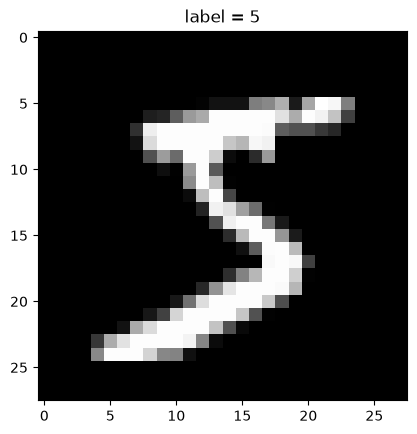

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"label = {y_train[0]}"); plt.show()

In [6]:
class MLP_MNIST(nn.Module):
    def __init__(self):
        super().__init__()

        self.mlp_stack = nn.Sequential(
        nn.Linear(784,  16),
        nn.ReLU(),
        nn.Linear(16, 16),
        nn.ReLU(),
        nn.Linear(16, 10)
        )
        
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        return self.mlp_stack(x)

In [7]:
class MLP_MNIST_2(nn.Module):
    def __init__(self):
        super().__init__()

        self.mlp_stack = nn.Sequential(
        nn.Linear(784,  256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
        )
        
    def forward(self,x):
        x = x.view(x.shape[0],-1)
        return self.mlp_stack(x)

In [8]:
model = MLP_MNIST().to(device)


In [9]:
#Hyper-paramaeters
nums_epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)


In [10]:
def train_loop(model, train_loader, criterion, optimizer):
  model.train()

  running_loss = 0
  correct = 0
  total = 0

  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    # Prediction
    logits = model(images)

    # Compute the loss
    loss = criterion(logits,labels)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()

    # Weight update
    optimizer.step()

    running_loss += loss.item()

    predictions = torch.argmax(logits,dim = 1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

  epoch_loss = running_loss / len(train_loader)
  epoch_acc = correct / total

  print(f"Train Loss : {epoch_loss:.4f} | Train Acc : {epoch_acc:.4f}")


In [11]:
for epoch in range(nums_epochs):
    print(f"Epoch : {epoch+1}")
    train_loop(model,train_loaders,criterion,optimizer)

Epoch : 1
Train Loss : 0.7457 | Train Acc : 0.7812
Epoch : 2
Train Loss : 0.3549 | Train Acc : 0.8949
Epoch : 3
Train Loss : 0.3180 | Train Acc : 0.9067
Epoch : 4
Train Loss : 0.2975 | Train Acc : 0.9127
Epoch : 5
Train Loss : 0.2818 | Train Acc : 0.9176
Epoch : 6
Train Loss : 0.2690 | Train Acc : 0.9207
Epoch : 7
Train Loss : 0.2572 | Train Acc : 0.9248
Epoch : 8
Train Loss : 0.2471 | Train Acc : 0.9286
Epoch : 9
Train Loss : 0.2385 | Train Acc : 0.9300
Epoch : 10
Train Loss : 0.2313 | Train Acc : 0.9324


In [12]:
model_2 = MLP_MNIST_2().to(device)
optimizer_2 = optim.Adam(model_2.parameters(),lr=0.001)

In [13]:
for epoch in range(nums_epochs):
    print(f"Epoch : {epoch+1}")
    train_loop(model_2,train_loaders,criterion,optimizer_2)

Epoch : 1
Train Loss : 0.3914 | Train Acc : 0.8836
Epoch : 2
Train Loss : 0.1707 | Train Acc : 0.9484
Epoch : 3
Train Loss : 0.1239 | Train Acc : 0.9623
Epoch : 4
Train Loss : 0.0968 | Train Acc : 0.9698
Epoch : 5
Train Loss : 0.0781 | Train Acc : 0.9753
Epoch : 6
Train Loss : 0.0668 | Train Acc : 0.9786
Epoch : 7
Train Loss : 0.0575 | Train Acc : 0.9813
Epoch : 8
Train Loss : 0.0512 | Train Acc : 0.9831
Epoch : 9
Train Loss : 0.0463 | Train Acc : 0.9848
Epoch : 10
Train Loss : 0.0427 | Train Acc : 0.9867


In [16]:
def test_loop(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images,labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            predictions = torch.argmax(logits,dim = 1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    epoch_acc = correct / total
    print(f"Test Acc : {epoch_acc:.4f}")

In [17]:
test_loop(model,test_loaders)

Test Acc : 0.9319


In [18]:
test_loop(model_2,test_loaders)

Test Acc : 0.9750


In [19]:
class MLP_MNIST_3(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.mlp_stack = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.mlp_stack(x)

In [23]:
model_3 = MLP_MNIST_3().to(device)
optimiser_3 = optim.Adam(model_3.parameters(), lr=0.001)

In [24]:
for epoch in range(nums_epochs):
    print(f"Epoch : {epoch+1}")
    train_loop(model_3,train_loaders,criterion,optimiser_3)

Epoch : 1
Train Loss : 0.4862 | Train Acc : 0.8490
Epoch : 2
Train Loss : 0.2415 | Train Acc : 0.9271
Epoch : 3
Train Loss : 0.1929 | Train Acc : 0.9418
Epoch : 4
Train Loss : 0.1680 | Train Acc : 0.9488
Epoch : 5
Train Loss : 0.1518 | Train Acc : 0.9539
Epoch : 6
Train Loss : 0.1395 | Train Acc : 0.9569
Epoch : 7
Train Loss : 0.1337 | Train Acc : 0.9591
Epoch : 8
Train Loss : 0.1277 | Train Acc : 0.9603
Epoch : 9
Train Loss : 0.1191 | Train Acc : 0.9631
Epoch : 10
Train Loss : 0.1104 | Train Acc : 0.9650


In [25]:
test_loop(model_3,test_loaders)

Test Acc : 0.9759
